# LightGBM Text Report Viewer

Prints the raw `DETAILED CLASSIFICATION REPORT` and `CONFUSION MATRIX` sections from `LightGBM_2.txt`.

In [ ]:
from pathlib import Path


In [70]:
txt_path = Path("LightGBM._1.txt")
text = txt_path.read_text(encoding="utf-8", errors="ignore")
eval_idx = text.rfind("EVALUATION METRICS")
test_text = text[eval_idx:] if eval_idx != -1 else text

def extract_section(test_text, header):
    if header not in text:
        return "[Section not found]"
    start = text.index(header)
    rest = text[start:]
    parts = rest.split("\n\n", 1)
    return parts[0]

print(extract_section(test_text, "DETAILED CLASSIFICATION REPORT"))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support


In [71]:
import pandas as pd
import re                                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                            
def extract_block(text, header, end_header):                                                                                                                                                                                                                  
  if header not in text:                                                                                                                                                                                                                                    
      return "[Section not found]"                                                                                                                                                                                                                          
  start = text.index(header)                                                                                                                                                                                                                                
  rest = text[start:]                                                                                                                                                                                                                                       
  if end_header in rest:                                                                                                                                                                                                                                    
      return rest[:rest.index(end_header)].strip()                                                                                                                                                                                                          
  return rest.strip()                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                            
dataset_info = extract_block(text, "[DATASET INFO]", "[CLASS DISTRIBUTION]")                                                                                                                                                                                  
print(dataset_info)                                                                                                                                                                                                                                           
                                                                                                                                                                                                                                                            
class_dist_block = extract_block(text, "[CLASS DISTRIBUTION]", "[FEATURE NORMALIZATION]")                                                                                                                                                                     
                                                                                                                                                                                                                                                            
rows = []                                                                                                                                                                                                                                                     
for line in class_dist_block.splitlines():                                                                                                                                                                                                                    
  if ":" not in line:                                                                                                                                                                                                                                       
      continue
  parts = line.split(":", 1)                                                                                                                                                                                                                                
  label = parts[0].strip()                                                                                                                                                                                                                                  
  if not label:                                                                                                                                                                                                                                             
      continue                                                                                                                                                                                                                                              
  train_match = re.search(r"Train=\s*(\d+)", parts[1])                                                                                                                                                                                                      
  val_match = re.search(r"Val=\s*(\d+)", parts[1])                                                                                                                                                                                                          
  train_pct = re.search(r"Train=\s*\d+\s*\(\s*([\d.]+)%\)", parts[1])                                                                                                                                                                                       
  val_pct = re.search(r"Val=\s*\d+\s*\(\s*([\d.]+)%\)", parts[1])                                                                                                                                                                                           
  rows.append({                                                                                                                                                                                                                                             
      "label": label,                                                                                                                                                                                                                                       
      "train": int(train_match.group(1)) if train_match else None,                                                                                                                                                                                          
      "train_%": float(train_pct.group(1)) if train_pct else None,
      "val": int(val_match.group(1)) if val_match else None,                                                                                                                                                                                                
      "val_%": float(val_pct.group(1)) if val_pct else None,                                                                                                                                                                                                
  })                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                            
class_dist_df = pd.DataFrame(rows).set_index("label")                                                                                                                                                                                                         
                                                                                                                                                                                                                                                            
styled = (
  class_dist_df.style
  .format({"train_%": "{:.1f}%", "val_%": "{:.1f}%"})                                                                                                                                                                                                       
  .set_properties(**{"text-align": "right"})
  .set_table_styles([                                                                                                                                                                                                                                       
      {"selector": "th", "props": [("text-align", "left")]}                                                                                                                                                                                                 
  ])                                                                                                                                                                                                                                                        
)                                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                            
styled 

[DATASET INFO]
  Training samples: 5446
  Validation samples: 1167
  Features: 42
  Classes: ['benign', 'dns', 'ldap', 'mixed', 'mssql', 'netbios', 'ntp', 'portmap', 'snmp', 'ssdp', 'syn', 'tftp', 'udp', 'webddos']


,train,train_%,val,val_%
label,,,,
benign,376,6.9%,81,6.9%
dns,376,6.9%,80,6.9%
ldap,376,6.9%,81,6.9%
mixed,600,11.0%,128,11.0%
mssql,376,6.9%,80,6.9%
netbios,376,6.9%,81,6.9%
ntp,375,6.9%,81,6.9%
portmap,376,6.9%,80,6.9%
snmp,376,6.9%,80,6.9%


In [72]:
val_block = extract_block(text, "[VALIDATION RESULTS]", "[EXPORT]")
#print(val_block)

val_rows = []
for line in val_block.splitlines():
    parts = line.split()
    if len(parts) != 5:
        continue
    label = parts[0]
    try:
        precision = float(parts[1])
        recall = float(parts[2])
        f1 = float(parts[3])
        support = int(parts[4])
    except ValueError:
        continue
    val_rows.append((label, precision, recall, f1, support))

val_df = pd.DataFrame(
    val_rows,
    columns=["label", "precision", "recall", "f1-score", "support"]
).set_index("label")
val_df


,precision,recall,f1-score,support
label,,,,
benign,1.00,0.96,0.98,81
dns,1.00,0.97,0.99,80
ldap,0.99,1.00,0.99,81
mixed,0.98,1.00,0.99,128
mssql,1.00,0.97,0.99,80
netbios,1.00,0.99,0.99,81
ntp,1.00,0.98,0.99,81
portmap,1.00,0.99,0.99,80
snmp,1.00,0.97,0.99,80


In [77]:
# Test metrics block (Per-Class Metrics section)
test_block = extract_block(text, "Per-Class Metrics:", "Weighted Averages:")
print(test_block)

test_rows = []
for line in test_block.splitlines():
    parts = line.split()
    if len(parts) != 4:
        continue
    label = parts[0]
    try:
        precision = float(parts[1])
        recall = float(parts[2])
        f1 = float(parts[3])
    except ValueError:
        continue
    test_rows.append((label, precision, recall, f1))

test_df = pd.DataFrame(
    test_rows,
    columns=["label", "precision", "recall", "f1-score"]
).set_index("label")
test_df


Per-Class Metrics:
----------------------------------------------------------------------
Class           Precision    Recall       F1-Score    
----------------------------------------------------------------------
benign          1.000        0.950        0.974       
dns             1.000        1.000        1.000       
ldap            1.000        0.988        0.994       
mixed           0.985        0.992        0.988       
mssql           1.000        0.988        0.994       
netbios         1.000        1.000        1.000       
ntp             1.000        1.000        1.000       
portmap         1.000        0.988        0.994       
snmp            1.000        1.000        1.000       
ssdp            1.000        1.000        1.000       
syn             1.000        0.988        0.994       
tftp            1.000        1.000        1.000       
udp             1.000        0.988        0.994       
webddos         0.900        1.000        0.947


,precision,recall,f1-score
label,,,
benign,1.000,0.950,0.974
dns,1.000,1.000,1.000
ldap,1.000,0.988,0.994
mixed,0.985,0.992,0.988
mssql,1.000,0.988,0.994
netbios,1.000,1.000,1.000
ntp,1.000,1.000,1.000
portmap,1.000,0.988,0.994
snmp,1.000,1.000,1.000


In [74]:
# Test weighted averages
weighted_block = extract_block(test_text, "Weighted Averages:", "CONFUSION MATRIX")
print(weighted_block)

weighted_rows = []
for line in weighted_block.splitlines():
    if ":" not in line:
        continue
    key, val = line.split(":", 1)
    key = key.strip()
    try:
        value = float(val.strip())
    except ValueError:
        continue
    weighted_rows.append((key, value))

weighted_df = pd.DataFrame(weighted_rows, columns=["metric", "value"]).set_index("metric")
weighted_df


Weighted Averages:
----------------------------------------------------------------------
Precision: 0.992
Recall:    0.991
F1-Score:  0.992



,value
metric,
Precision,0.992
Recall,0.991
F1-Score,0.992


In [75]:
print(extract_section(test_text, "CONFUSION MATRIX"))


CONFUSION MATRIX
True\Pred      benign      dns         ldap        mixed       mssql       netbios     ntp         portmap     snmp        ssdp        syn         tftp        udp         webddos     
----------------------------------------------------------------------
benign         76          0           0           2           0           0           0           0           0           0           0           0           0           2           
dns            0           81          0           0           0           0           0           0           0           0           0           0           0           0           
ldap           0           0           79          0           0           0           0           0           0           0           0           0           0           1           
mixed          0           0           0           128         0           0           0           0           0           0           0           0           0           1    

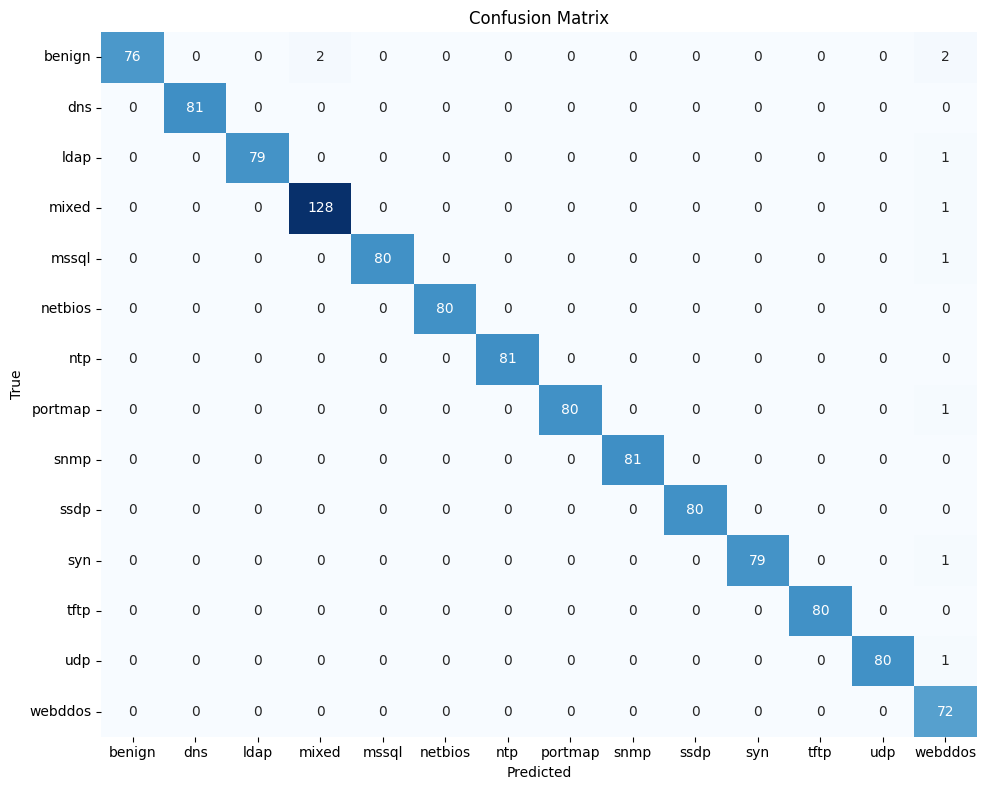

,benign,dns,ldap,mixed,mssql,netbios,ntp,portmap,snmp,ssdp,syn,tftp,udp,webddos
benign,76,0,0,2,0,0,0,0,0,0,0,0,0,2
dns,0,81,0,0,0,0,0,0,0,0,0,0,0,0
ldap,0,0,79,0,0,0,0,0,0,0,0,0,0,1
mixed,0,0,0,128,0,0,0,0,0,0,0,0,0,1
mssql,0,0,0,0,80,0,0,0,0,0,0,0,0,1
netbios,0,0,0,0,0,80,0,0,0,0,0,0,0,0
ntp,0,0,0,0,0,0,81,0,0,0,0,0,0,0
portmap,0,0,0,0,0,0,0,80,0,0,0,0,0,1
snmp,0,0,0,0,0,0,0,0,81,0,0,0,0,0
ssdp,0,0,0,0,0,0,0,0,0,80,0,0,0,0


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_text = extract_section(test_text, "CONFUSION MATRIX")
cm_lines = cm_text.splitlines()

header_idx = None
for i, line in enumerate(cm_lines):
    if line.strip().startswith("True\\Pred"):
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Confusion matrix header not found.")

labels = cm_lines[header_idx].split()[1:]
rows = []
for line in cm_lines[header_idx + 1:]:
    if not line.strip() or line.strip().startswith("-"):
        continue
    parts = line.split()
    if len(parts) < 2:
        continue
    values = [int(x) for x in parts[1:] if x.isdigit()]
    if values:
        rows.append(values)

cm = np.array(rows)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

cm_df
